In [14]:
# --- Mount your trained CORnet-Z detection model + run a quick test on images ---

import sys
from pathlib import Path
import csv

import torch
import torch.nn as nn
import torchvision
from PIL import Image


CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet") 
CHECKPOINT_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/conret_coco_bboxes/cornets/identification_critical/epoch_200.pth.tar")     
IMAGE_PATHS = [
    "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000004901.jpg",     
]

# 2) Import cornet repo
sys.path.insert(0, str(CORN_NET_REPO))
import cornet
print("Imported cornet from:", cornet.__file__)

# 3) Rebuild label mapping (must match training!)
#    Your training mapping was: sorted unique category_name from train_csv.
def build_label_map_from_csv(csv_path, expected_classes=None):
    labels = set()
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            labels.add(row["category_name"])
    labels = sorted(labels)
    if expected_classes is not None and len(labels) != expected_classes:
        print(f"WARNING: found {len(labels)} unique category_name values in {csv_path} "
              f"(expected {expected_classes}).")
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

# 4) Define the SAME model wrapper you trained
class CornetDetectionWrapper(nn.Module):
    def __init__(self, base_model, num_classes, num_slots=5):
        super().__init__()
        if hasattr(base_model, "module"):
            base_model = base_model.module

        self.backbone = base_model
        self.num_classes = num_classes
        self.num_slots = num_slots

        # Remove original classifier
        self.backbone.decoder.linear = nn.Identity()

        feat_dim = 512  # CORnet-Z decoder output dim
        self.class_head = nn.Linear(feat_dim, num_slots * num_classes)
        self.box_head   = nn.Linear(feat_dim, num_slots * 4)

    def forward(self, x):
        feats = self.backbone(x)  # [B, 512]
        B = feats.shape[0]

        class_logits = self.class_head(feats).view(B, self.num_slots, self.num_classes)
        box_preds = torch.sigmoid(self.box_head(feats)).view(B, self.num_slots, 4)  # normalized (0..1) xyxy
        return class_logits, box_preds

# 5) Load checkpoint + construct model with the checkpoint's flags

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
flags = ckpt.get("flags", {})
model_letter = str(flags.get("model", "S")).lower()  # 'z','r','rt','s'
num_classes = ckpt["state_dict"]["class_head.weight"].shape[0] // 5
num_slots    = 5
times        = int(flags.get("times", 5))

# Build base CORnet
base_ctor = getattr(cornet, f"cornet_{model_letter}")
if model_letter == "r":
    base_model = base_ctor(pretrained=False, map_location=device, times=times)
else:
    base_model = base_ctor(pretrained=False, map_location=device)

model = CornetDetectionWrapper(base_model, num_classes=num_classes, num_slots=num_slots).to(device)

# Load weights (handle DataParallel checkpoints too)
state = ckpt["state_dict"]
try:
    model.load_state_dict(state, strict=True)
except RuntimeError:
    # common fix if keys are like "module.xxx"
    fixed = {k.replace("module.", "", 1): v for k, v in state.items()}
    model.load_state_dict(fixed, strict=True)

model.eval()
print(f"Loaded checkpoint from: {CHECKPOINT_PATH}")
print(f"Model: CORnet-{model_letter.upper()}  | num_classes={num_classes} | num_slots={num_slots} | device={device}")

# label mapping from the SAME train_csv used during training
train_csv_path = flags.get("train_csv", None)
idx_to_label = None
if train_csv_path:
    _, idx_to_label = build_label_map_from_csv(train_csv_path, expected_classes=num_classes)
    print("Label map rebuilt from:", train_csv_path)
else:
    print("NOTE: checkpoint has no flags['train_csv']; you'll only get class indices (0..C-1).")

# 6) Preprocess + inference helpers
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                            std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    normalize,
])

@torch.no_grad()
def run_images(image_paths, topk_per_slot=3):
    imgs = []
    for p in image_paths:
        im = Image.open(p).convert("RGB")
        imgs.append(transform(im))
    x = torch.stack(imgs, dim=0).to(device)

    class_logits, box_preds = model(x)  # [B,K,C], [B,K,4]
    probs = torch.softmax(class_logits, dim=-1)

    results = []
    B, K, C = probs.shape
    for b in range(B):
        per_slot = []
        for k in range(K):
            topv, topi = probs[b, k].topk(topk_per_slot)
            top_items = []
            for v, i in zip(topv.tolist(), topi.tolist()):
                lab = idx_to_label[i] if idx_to_label is not None else i
                top_items.append((lab, float(v)))
            box = box_preds[b, k].tolist()  # [x1,y1,x2,y2] normalized to 0..1 (relative to 224x224)
            per_slot.append({"slot": k, "box_xyxy_norm": box, "top": top_items})
        results.append(per_slot)
    return results

# 7) Run the test
out = run_images(IMAGE_PATHS, topk_per_slot=3)

for img_path, slots in zip(IMAGE_PATHS, out):
    print("\n" + "="*90)
    print("IMAGE:", img_path)
    for s in slots:
        print(f"  slot {s['slot']}: box(x1,y1,x2,y2)={['{:.3f}'.format(x) for x in s['box_xyxy_norm']]}")
        for lab, pr in s["top"]:
            print(f"     - {lab}: {pr:.4f}")

Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
Loaded checkpoint from: /zpool/vladlab/data_drive/geogaze_data/conret_coco_bboxes/cornets/identification_critical/epoch_200.pth.tar
Model: CORnet-S  | num_classes=70 | num_slots=5 | device=cuda
Label map rebuilt from: /zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/instances_train_filtered3_bboxes.csv

IMAGE: /zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000004901.jpg
  slot 0: box(x1,y1,x2,y2)=['0.156', '0.287', '0.957', '0.992']
     - toilet: 0.1369
     - giraffe: 0.1075
     - zebra: 0.1066
  slot 1: box(x1,y1,x2,y2)=['0.205', '0.165', '0.825', '0.845']
     - zebra: 0.0763
     - elephant: 0.0523
     - dining table: 0.0484
  slot 2: box(x1,y1,x2,y2)=['0.428', '0.345', '0.696', '0.699']
     - dining table: 0.1189
     - chair: 0.0517
     - couch: 0.0477
  slot 3: box(x1,y1,x2,y2)=['0.449', '0.468', '

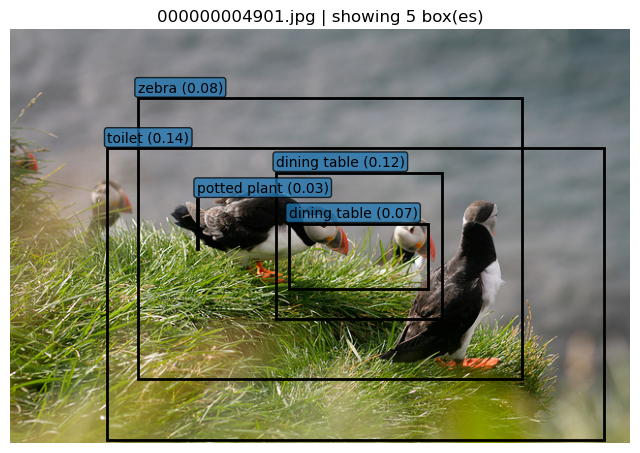

In [16]:


from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SHOW_TOP_BOXES = 5        # <-- set to 1, 2, 3, ...
SCORE_MODE = "slot_top1"  # "slot_top1" (recommended) or "slot_maxlogit"
TOPK_LABELS_PER_BOX = 1   # how many labels to print per box (1 is cleanest)

# Optional: only draw boxes above this probability (set None to disable)
MIN_TOP1_PROB = None      # e.g., 0.20

def _slot_score(slot_dict):
    """
    slot_dict is one element from run_images() output:
      {"slot": k, "box_xyxy_norm": [...], "top": [(lab, prob), ...]}
    """
    if SCORE_MODE == "slot_top1":
        return slot_dict["top"][0][1] if slot_dict["top"] else float("-inf")
    elif SCORE_MODE == "slot_maxlogit":
        # Not available with current run_images() return (we only kept probs).
        # Keeping this option here in case you later return logits too.
        return slot_dict["top"][0][1] if slot_dict["top"] else float("-inf")
    else:
        raise ValueError(f"Unknown SCORE_MODE: {SCORE_MODE}")

def draw_predictions_on_image(
    image_path: str,
    slots: list,
    show_top_boxes: int = 2,
    topk_labels_per_box: int = 1,
    min_top1_prob: float | None = None,
):
    """
    image_path: path to original image
    slots: per-image list from run_images() (length K=num_slots)
    Boxes are normalized xyxy in 0..1 corresponding to 224x224 input resize.
    We will draw them onto the original image by scaling with (W,H).
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    # Sort slots by chosen score (usually top1 prob) and take top N
    slots_sorted = sorted(slots, key=_slot_score, reverse=True)

    chosen = []
    for s in slots_sorted:
        top1_prob = s["top"][0][1] if s["top"] else 0.0
        if (min_top1_prob is not None) and (top1_prob < min_top1_prob):
            continue
        chosen.append(s)
        if len(chosen) >= show_top_boxes:
            break

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis("off")

    for s in chosen:
        x1n, y1n, x2n, y2n = s["box_xyxy_norm"]
        # normalized -> pixel coords in ORIGINAL image
        x1, x2 = x1n * W, x2n * W
        y1, y2 = y1n * H, y2n * H

        # clamp for safety
        x1 = max(0, min(W, x1)); x2 = max(0, min(W, x2))
        y1 = max(0, min(H, y1)); y2 = max(0, min(H, y2))

        bw = max(1.0, x2 - x1)
        bh = max(1.0, y2 - y1)

        rect = Rectangle((x1, y1), bw, bh, fill=False, linewidth=2)
        ax.add_patch(rect)

        # Build label text
        lines = []
        for lab, pr in s["top"][:topk_labels_per_box]:
            lines.append(f"{lab} ({pr:.2f})")
        label_text = "\n".join(lines) if lines else "?"

        # Put label near top-left of box
        ax.text(
            x1,
            max(0, y1 - 4),
            label_text,
            fontsize=10,
            verticalalignment="bottom",
            bbox=dict(boxstyle="round,pad=0.2", alpha=0.75),
        )

    ax.set_title(f"{Path(image_path).name} | showing {len(chosen)} box(es)")
    plt.show()

out = run_images(IMAGE_PATHS, topk_per_slot=max(TOPK_LABELS_PER_BOX, 3))

for img_path, slots in zip(IMAGE_PATHS, out):
    draw_predictions_on_image(
        img_path,
        slots,
        show_top_boxes=SHOW_TOP_BOXES,
        topk_labels_per_box=TOPK_LABELS_PER_BOX,
        min_top1_prob=MIN_TOP1_PROB,
    )

In [ ]:
import torch
from PIL import Image
import torchvision

# Pick TWO different images
IMG_A = "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000000144.jpg"
IMG_B = "/zpool/vladlab/data_drive/stimulus_sets/geogaze_COCO_stim/coco_working/working_v3/train_working3/000000000581.jpg"

normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                            std=[0.229, 0.224, 0.225])
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    normalize,
])

def load_tensor(p):
    im = Image.open(p).convert("RGB")
    x = transform(im)  # [3,224,224]
    return x

xA = load_tensor(IMG_A)
xB = load_tensor(IMG_B)

print("Image tensors identical?", torch.allclose(xA, xB))
print("Tensor diff (max abs):", (xA - xB).abs().max().item())

model.eval()
with torch.no_grad():
    inp = torch.stack([xA, xB], dim=0).to(device)  # [2,3,224,224]
    class_logits, box_preds = model(inp)           # [2,K,C], [2,K,4]

# How different are the raw outputs?
logit_diff = (class_logits[0] - class_logits[1]).abs()
box_diff   = (box_preds[0] - box_preds[1]).abs()

print("Class logits diff: mean =", logit_diff.mean().item(), "max =", logit_diff.max().item())
print("Box preds   diff: mean =", box_diff.mean().item(),   "max =", box_diff.max().item())

In [ ]:
with torch.no_grad():
    feats = model.backbone(inp)  # [2, 512]

feat_diff = (feats[0] - feats[1]).abs()
print("Backbone feature diff: mean =", feat_diff.mean().item(),
      "max =", feat_diff.max().item())